In [12]:
!git clone https://github.com/Deeptixx/ceam_task_1.git

fatal: destination path 'ceam_task_1' already exists and is not an empty directory.


In [13]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [14]:
data_dir = '/kaggle/working/ceam_task_1/dataset'
classes = ['phone', 'book', 'headphones', 'calculator', 'clock']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
image_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(data_dir, class_name)
    for img_file in os.listdir(class_dir):
        if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(class_to_idx[class_name])
print(f"Total images: {len(image_paths)}")
print(f"Class distribution: {np.bincount(labels)}")

Total images: 125
Class distribution: [25 25 25 25 25]


In [15]:
images = []
for img_path in image_paths:
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    images.append(img_array)
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}")  #(125,224,224,3)
print(f"Labels shape: {labels.shape}")  #(125,)
images = images / 255.0 #normalizing pixel values

Images shape: (125, 224, 224, 3)
Labels shape: (125,)


In [16]:
# 70% train 15% val 15% test
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=SEED, stratify=labels
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")
print(f"\nTrain class distribution: {np.bincount(train_labels)}")
print(f"Val class distribution: {np.bincount(val_labels)}")
print(f"Test class distribution: {np.bincount(test_labels)}")

Train: 87, Val: 19, Test: 19

Train class distribution: [17 18 17 17 18]
Val class distribution: [4 3 4 4 4]
Test class distribution: [4 4 4 4 3]


In [17]:
def create_baseline_model(dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', 
                      input_shape=(224, 224, 3)),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(5, activation='softmax')
    ])
    
    return model
model = create_baseline_model(dropout_rate=0.5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
base_model = create_baseline_model(dropout_rate=0.5)
initial_weights = base_model.get_weights()

In [19]:
model_d0 = create_baseline_model(dropout_rate=0.0)
model_d0.set_weights(initial_weights)

model_d0.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_d0 = model_d0.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_d0, test_acc_d0 = model_d0.evaluate(
    test_images, test_labels, verbose=0
)
print(f"Dropout Rate 0.0Test Accuracy: {test_acc_d0*100:.2f}%")

Dropout Rate 0.0Test Accuracy: 89.47%


In [20]:
model_d03 = create_baseline_model(dropout_rate=0.3)
model_d03.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_d03 = model_d03.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_d03, test_acc_d03 = model_d03.evaluate(
    test_images, test_labels, verbose=0
)
print(f"Dropout Rate 0.3 Test Accuracy: {test_acc_d03*100:.2f}%")

Dropout Rate 0.3 Test Accuracy: 78.95%


In [21]:
model_d05 = create_baseline_model(dropout_rate=0.5)
model_d05.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_d05 = model_d05.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_d05, test_acc_d05 = model_d05.evaluate(
    test_images, test_labels, verbose=0
)

print(f"Dropout Rate 0.5 Test Accuracy: {test_acc_d03*100:.2f}%")

Dropout Rate 0.5 Test Accuracy: 78.95%


In [23]:
model_d07 = create_baseline_model(dropout_rate=0.7)
model_d07.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_d07 = model_d07.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_data=(val_images, val_labels),
    verbose=0
)

test_loss_d07, test_acc_d07 = model_d07.evaluate(
    test_images, test_labels, verbose=0
)

print(f"Dropout Rate 0.7 Test Accuracy: {test_acc_d07*100:.2f}%")

Dropout Rate 0.7 Test Accuracy: 84.21%


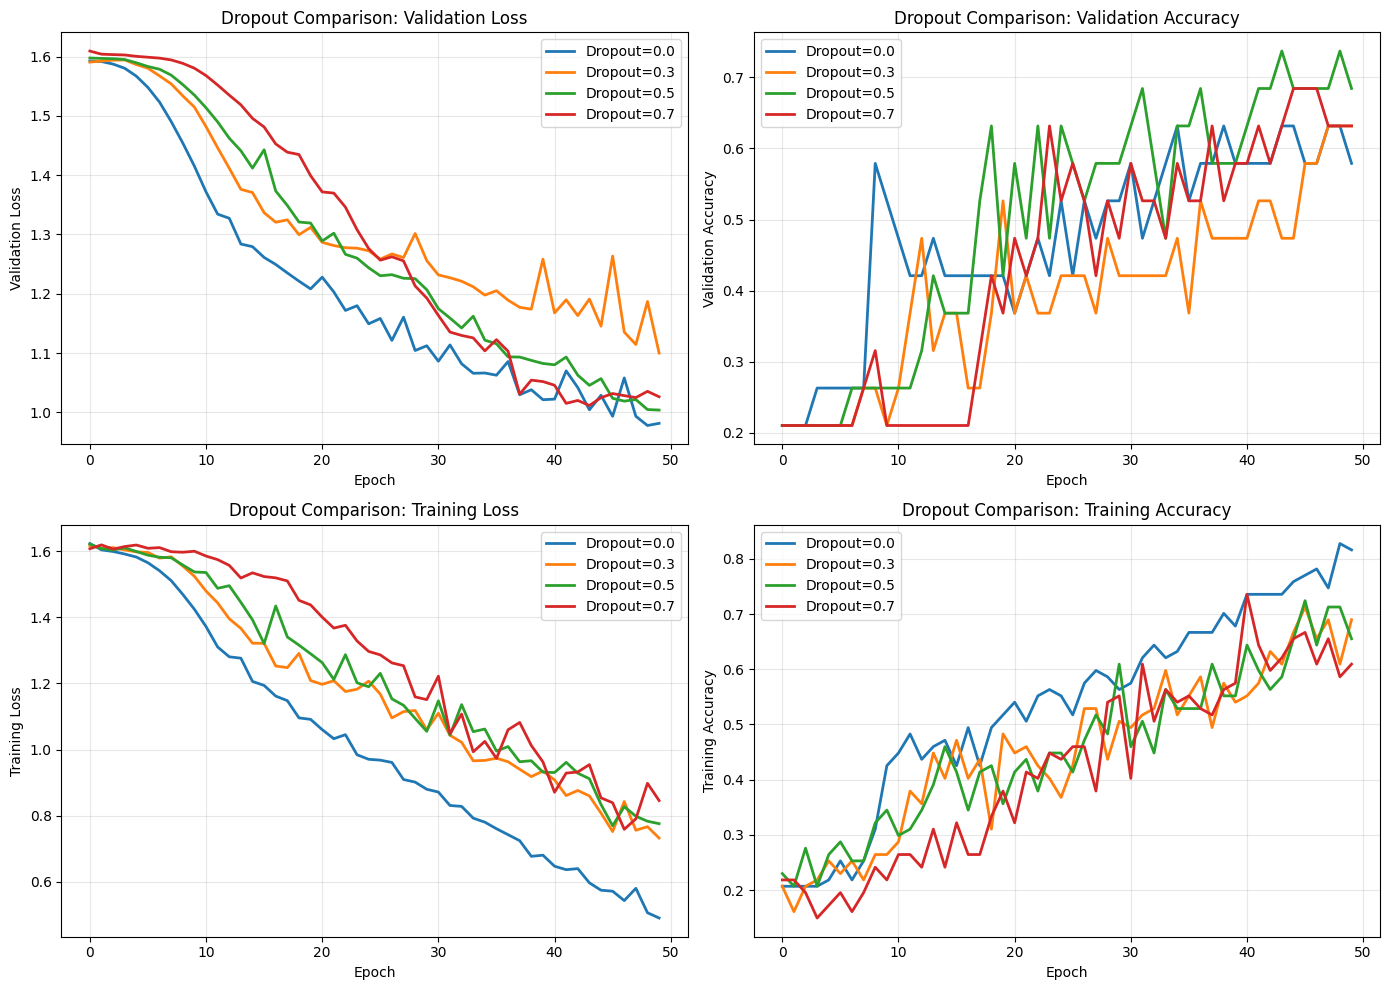

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Loss
axes[0, 0].plot(history_d0.history['val_loss'], label='Dropout=0.0', linewidth=2)
axes[0, 0].plot(history_d03.history['val_loss'], label='Dropout=0.3', linewidth=2)
axes[0, 0].plot(history_d05.history['val_loss'], label='Dropout=0.5', linewidth=2)
axes[0, 0].plot(history_d07.history['val_loss'], label='Dropout=0.7', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].set_title('Dropout Comparison: Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation Accuracy
axes[0, 1].plot(history_d0.history['val_accuracy'], label='Dropout=0.0', linewidth=2)
axes[0, 1].plot(history_d03.history['val_accuracy'], label='Dropout=0.3', linewidth=2)
axes[0, 1].plot(history_d05.history['val_accuracy'], label='Dropout=0.5', linewidth=2)
axes[0, 1].plot(history_d07.history['val_accuracy'], label='Dropout=0.7', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('Dropout Comparison: Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Training Loss
axes[1, 0].plot(history_d0.history['loss'], label='Dropout=0.0', linewidth=2)
axes[1, 0].plot(history_d03.history['loss'], label='Dropout=0.3', linewidth=2)
axes[1, 0].plot(history_d05.history['loss'], label='Dropout=0.5', linewidth=2)
axes[1, 0].plot(history_d07.history['loss'], label='Dropout=0.7', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('Dropout Comparison: Training Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Training Accuracy
axes[1, 1].plot(history_d0.history['accuracy'], label='Dropout=0.0', linewidth=2)
axes[1, 1].plot(history_d03.history['accuracy'], label='Dropout=0.3', linewidth=2)
axes[1, 1].plot(history_d05.history['accuracy'], label='Dropout=0.5', linewidth=2)
axes[1, 1].plot(history_d07.history['accuracy'], label='Dropout=0.7', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Training Accuracy')
axes[1, 1].set_title('Dropout Comparison: Training Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()